In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
data = pd.read_csv("advertising.csv.csv")

# Show first rows
print(data.head())

# Features (inputs) and target (output)
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Polynomial Features (degree = 3 for diminishing returns)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict
y_pred = model.predict(X_test_poly)

# Evaluate model
print("R2 Score:", r2_score(y_test, y_pred))

# Example Prediction
# Format: [TV, Radio, Newspaper]
example = np.array([[200, 40, 50]])
example_poly = poly.transform(example)
prediction = model.predict(example_poly)

print("Predicted Sales:", prediction[0])

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
R2 Score: 0.9413558587032341
Predicted Sales: 20.058501691728008


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


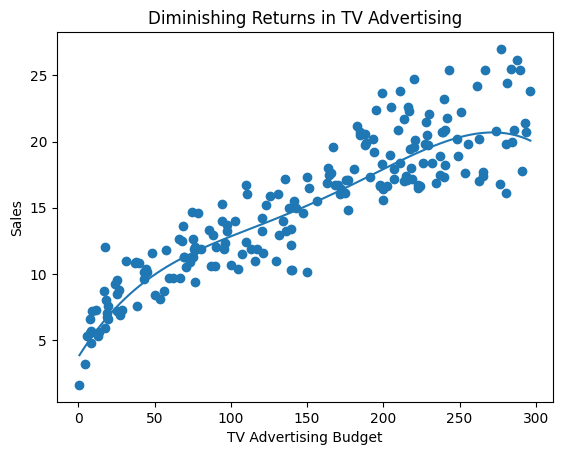

In [5]:
# Visualizing only TV vs Sales (keeping others average)

tv_range = np.linspace(data['TV'].min(), data['TV'].max(), 100)

# Use average values for Radio and Newspaper
radio_mean = data['Radio'].mean()
news_mean = data['Newspaper'].mean()

X_plot = np.array([[tv, radio_mean, news_mean] for tv in tv_range])
X_plot_poly = poly.transform(X_plot)

y_plot = model.predict(X_plot_poly)

plt.scatter(data['TV'], data['Sales'])
plt.plot(tv_range, y_plot)
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("Diminishing Returns in TV Advertising")
plt.show()